# EDA in Pandas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("world_population.csv")
df.head()

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771.0,38972230.0,33753499.0,28189672.0,19542982.0,10694796.0,12486631.0,10752971.0,652230.0,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321.0,2866849.0,2882481.0,2913399.0,3182021.0,3295066.0,2941651.0,2324731.0,28748.0,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225.0,43451666.0,39543154.0,35856344.0,30774621.0,25518074.0,18739378.0,13795915.0,2381741.0,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.0,46189.0,51368.0,54849.0,58230.0,47818.0,32886.0,27075.0,199.0,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824.0,77700.0,71746.0,71519.0,66097.0,53569.0,35611.0,19860.0,468.0,170.5641,1.0100,0.00


In [6]:
df.loc[:, df.columns.str.contains("Cap")].head()

,Capital
0,Kabul
1,Tirana
2,Algiers
3,Pago Pago
4,Andorra la Vella


In [20]:
#how you can search for the function that you need
s = pd.Series(dir(df))
s[s.str.contains("sel")]

367    select_dtypes
dtype: str

In [26]:
#?df.select_dtypes

In [61]:
df.select_dtypes(include = "number").head()

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,41128771.00,38972230.00,33753499.00,28189672.00,19542982.00,10694796.00,12486631.00,10752971.00,652230.00,63.06,1.03,0.52
1,138,2842321.00,2866849.00,2882481.00,2913399.00,3182021.00,3295066.00,2941651.00,2324731.00,28748.00,98.87,1.00,0.04
2,34,44903225.00,43451666.00,39543154.00,35856344.00,30774621.00,25518074.00,18739378.00,13795915.00,2381741.00,18.85,1.02,0.56
3,213,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
4,203,79824.00,77700.00,71746.00,71519.00,66097.00,53569.00,35611.00,19860.00,468.00,170.56,1.01,0.00


In [4]:
df.groupby("Continent")["2020 Population"].max()

Continent
Africa           2.083274e+08
Asia             1.424930e+09
Europe           1.456173e+08
North America    3.359420e+08
Oceania          2.567005e+07
South America    2.131963e+08
Name: 2020 Population, dtype: float64

In [73]:
df.groupby("Continent").agg({"2020 Population":["max","min","sum", "count"]})

2020 Population                              
                          max       min           sum count
Continent                                                  
Africa           208327405.00 105530.00 1360671810.00    57
Asia            1424929781.00 441725.00 4652801584.00    49
Europe           145617329.00    520.00  745792196.00    50
North America    335942003.00   4500.00  594236593.00    40
Oceania           25670051.00   1827.00   43933426.00    23
South America    213196304.00   3747.00  431530043.00    14

In [62]:
df.select_dtypes(include = "string").head()

,CCA3,Country,Capital,Continent
0,AFG,Afghanistan,Kabul,Asia
1,ALB,Albania,Tirana,Europe
2,DZA,Algeria,Algiers,Africa
3,ASM,American Samoa,Pago Pago,Oceania
4,AND,Andorra,Andorra la Vella,Europe


In [63]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    str    
 2   Country                      234 non-null    str    
 3   Capital                      234 non-null    str    
 4   Continent                    234 non-null    str    
 5   2022 Population              230 non-null    float64
 6   2020 Population              233 non-null    float64
 7   2015 Population              230 non-null    float64
 8   2010 Population              227 non-null    float64
 9   2000 Population              227 non-null    float64
 10  1990 Population              229 non-null    float64
 11  1980 Population              229 non-null    float64
 12  1970 Population              230 non-null    float64
 13  Area (km²)                   23

In [64]:
df.describe()

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.00,230.00,233.00,230.00,227.00,227.00,229.00,229.00,230.00,232.00,230.00,232.00,234.00
mean,117.50,34632250.88,33600710.95,32066004.16,30270164.48,26840495.26,19330463.93,16282884.78,15866499.13,581663.75,456.81,1.01,0.43
std,67.69,137889172.44,135873196.61,131507146.34,126074183.54,113352454.57,81309624.96,69345465.54,68355859.75,1769133.06,2083.74,0.01,1.71
min,1.00,510.00,520.00,564.00,596.00,651.00,700.00,733.00,752.00,1.00,0.03,0.91,0.00
25%,59.25,419738.50,406471.00,394295.00,382726.50,329470.00,261928.00,223752.00,145880.50,2567.25,36.60,1.00,0.01
50%,117.50,5762857.00,5456681.00,5244415.00,4889741.00,4491202.00,3785847.00,3135123.00,2511718.00,77141.00,95.35,1.01,0.07
75%,175.75,22653719.00,21522626.00,19730853.75,16825852.50,15625467.00,11882762.00,9817257.00,8817329.00,414643.25,236.88,1.02,0.28
max,234.00,1425887337.00,1424929781.00,1393715448.00,1348191368.00,1264099069.00,1153704252.00,982372466.00,822534450.00,17098242.00,23172.27,1.07,17.88


`df.nunique()` counts **how many distinct values** appear in each column.

By default it uses **`dropna=True`**, so **missing values (`NaN`) are not counted** as a separate unique category—they are ignored. The number you see is the count of **non-null** distinct values only.

To treat all missing cells in a column as **one** extra category, use `df.nunique(dropna=False)`.


In [5]:
df.isnull().sum()

Rank                           0
CCA3                           0
Country                        0
Capital                        0
Continent                      0
2022 Population                4
2020 Population                1
2015 Population                4
2010 Population                7
2000 Population                7
1990 Population                5
1980 Population                5
1970 Population                4
Area (km²)                     2
Density (per km²)              4
Growth Rate                    2
World Population Percentage    0
dtype: int64

In [10]:
df.loc[df["2022 Population"].isnull()].reset_index()

,index,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,62,159,SWZ,Eswatini,Mbabane,Africa,NaN,1180655.0,1133936.0,1099920.0,1030496.0,854011.0,598564.0,442865.0,17364.0,69.2047,1.0079,0.02
1,154,120,NOR,Norway,Oslo,Europe,NaN,5379839.0,NaN,4889741.0,4491202.0,4241636.0,4085776.0,3875546.0,323802.0,16.7828,1.0058,0.07
2,157,222,PLW,Palau,Ngerulmud,Oceania,NaN,17972.0,17794.0,18540.0,19726.0,15293.0,12252.0,11366.0,459.0,39.3355,1.0017,0.00
3,207,155,TLS,Timor-Leste,Dili,Asia,NaN,1299995.0,1205813.0,1088486.0,NaN,758106.0,642224.0,554021.0,14874.0,90.1772,1.0154,0.02


In [11]:
df.nunique()

Rank                           234
CCA3                           234
Country                        234
Capital                        234
Continent                        6
2022 Population                230
2020 Population                233
2015 Population                230
2010 Population                227
2000 Population                227
1990 Population                229
1980 Population                229
1970 Population                230
Area (km²)                     231
Density (per km²)              230
Growth Rate                    178
World Population Percentage     70
dtype: int64

In [13]:
df.groupby(["Continent","Country"])["2022 Population"].sum()

Continent      Country     
Africa         Algeria         44903225.0
               Angola          35588987.0
               Benin           13352864.0
               Botswana         2630296.0
               Burkina Faso    22673762.0
                                  ...    
South America  Paraguay         6780744.0
               Peru            34049588.0
               Suriname          618040.0
               Uruguay          3422794.0
               Venezuela       28301696.0
Name: 2022 Population, Length: 234, dtype: float64

In [28]:
df.sort_values(by= ["Continent","Country"], ascending=[False,False]).head(10)

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
227,51,VEN,Venezuela,Caracas,South America,28301696.00,28490453.00,30529716.00,28715022.00,NaN,19750579.00,15210443.00,11355475.00,NaN,30.88,1.00,0.35
223,133,URY,Uruguay,Montevideo,South America,3422794.00,3429086.00,3402818.00,3352651.00,3292224.00,3117012.00,2953750.00,2790265.00,181034.00,18.91,1.00,0.04
199,170,SUR,Suriname,Paramaribo,South America,618040.00,607065.00,575475.00,546080.00,478998.00,412756.00,375112.00,379918.00,163820.00,3.77,1.01,0.01
162,44,PER,Peru,Lima,South America,34049588.00,33304756.00,30711863.00,29229572.00,26654439.00,22109099.00,17492406.00,13562371.00,1285216.00,26.49,1.01,0.43
161,109,PRY,Paraguay,Asunción,South America,6780744.00,6618695.00,6177950.00,5768613.00,5123819.00,4059195.00,3078912.00,2408787.00,406752.00,16.67,1.01,0.09
86,164,GUY,Guyana,Georgetown,South America,808726.00,797202.00,755031.00,747932.00,759051.00,747116.00,778176.00,705261.00,214969.00,3.76,1.01,0.01
69,184,GUF,French Guiana,Cayenne,South America,304557.00,290969.00,257026.00,228453.00,164351.00,113931.00,66825.00,46484.00,83534.00,3.65,1.02,0.00
64,231,FLK,Falkland Islands,Stanley,South America,3780.00,3747.00,3408.00,3187.00,3080.00,2332.00,2240.00,2274.00,12173.00,0.31,1.00,0.00
56,67,ECU,Ecuador,Quito,South America,18001000.00,17588595.00,16195902.00,14989585.00,12626507.00,10449837.00,8135845.00,6172215.00,276841.00,65.02,1.01,0.23
42,28,COL,Colombia,Bogota,South America,51874024.00,50930662.00,47119728.00,NaN,39215135.00,32601393.00,26176195.00,20905254.00,1141748.00,45.43,1.01,0.65


In [31]:
df.corr(numeric_only = True)

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Rank,1.00,-0.36,-0.36,-0.35,-0.35,-0.34,-0.33,-0.33,-0.34,-0.38,0.13,-0.22,-0.36
2022 Population,-0.36,1.00,1.00,1.00,1.00,0.99,0.99,0.99,0.97,0.45,-0.03,-0.02,1.00
2020 Population,-0.36,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.98,0.45,-0.03,-0.03,1.00
2015 Population,-0.35,1.00,1.00,1.00,1.00,1.00,0.99,0.99,0.98,0.46,-0.03,-0.03,1.00
2010 Population,-0.35,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.98,0.46,-0.03,-0.04,1.00
2000 Population,-0.34,0.99,1.00,1.00,1.00,1.00,1.00,1.00,0.99,0.47,-0.03,-0.05,0.99
1990 Population,-0.33,0.99,0.99,0.99,1.00,1.00,1.00,1.00,1.00,0.52,-0.03,-0.07,0.99
1980 Population,-0.33,0.99,0.99,0.99,0.99,1.00,1.00,1.00,1.00,0.53,-0.03,-0.08,0.99
1970 Population,-0.34,0.97,0.98,0.98,0.98,0.99,1.00,1.00,1.00,0.51,-0.03,-0.08,0.97
Area (km²),-0.38,0.45,0.45,0.46,0.46,0.47,0.52,0.53,0.51,1.00,-0.06,-0.01,0.45


<Axes: >

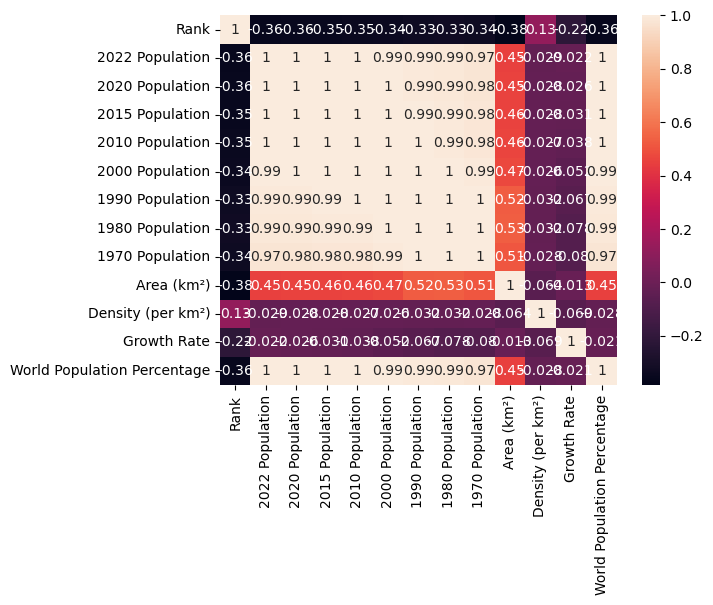

In [14]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

#plt.rcParams['figure.figsize'] = (20,7)

#plt.show()

In [15]:
df.groupby('Continent').mean(numeric_only = True).sort_values(by="2022 Population",ascending=False)

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Continent,,,,,,,,,,,,,
Asia,77.560000,9.632739e+07,9.495513e+07,8.916500e+07,8.908777e+07,8.058084e+07,4.864000e+07,4.027833e+07,4.383988e+07,6.427628e+05,1025.024136,1.009384,1.183800
South America,97.571429,3.120119e+07,3.082357e+07,2.950960e+07,2.678940e+07,2.501589e+07,2.122474e+07,1.727064e+07,1.378194e+07,1.301303e+06,20.971979,1.007957,0.391429
Africa,92.157895,2.545588e+07,2.387144e+07,2.141970e+07,1.889820e+07,1.459837e+07,1.137696e+07,8.586032e+06,6.567175e+06,5.378793e+05,126.406569,1.021180,0.313509
Europe,124.500000,1.505537e+07,1.491584e+07,1.502745e+07,1.471228e+07,1.481769e+07,1.478520e+07,1.420000e+07,1.311848e+07,4.602082e+05,663.324742,1.002256,0.186600
North America,160.925000,1.500740e+07,1.485591e+07,1.425960e+07,1.356802e+07,1.215174e+07,1.053166e+07,9.207334e+06,7.885865e+06,6.061044e+05,272.494118,1.004285,0.187750
Oceania,188.521739,2.046386e+06,1.910149e+06,1.756664e+06,1.613164e+06,1.357512e+06,1.162775e+06,9.965322e+05,8.469683e+05,3.702209e+05,132.543065,1.007383,0.023913


In [35]:
df[df['Continent'].str.contains('Oceania')].head()

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
3,213,ASM,American Samoa,Pago Pago,Oceania,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
11,55,AUS,Australia,Canberra,Oceania,26177413.00,25670051.00,23820236.00,22019168.00,19017963.00,17048003.00,14706322.00,12595034.00,7692024.00,3.40,1.01,0.33
44,223,COK,Cook Islands,Avarua,Oceania,17011.00,17029.00,17695.00,17212.00,15897.00,17123.00,17651.00,20470.00,236.00,72.08,1.00,0.00
66,162,FJI,Fiji,Suva,Oceania,929766.00,920422.00,917200.00,905169.00,832509.00,780430.00,644582.00,527634.00,18272.00,50.88,1.01,0.01
70,183,PYF,French Polynesia,Papeete,Oceania,306279.00,301920.00,291787.00,283788.00,250927.00,211089.00,163591.00,117891.00,4167.00,73.50,1.01,0.00


In [79]:
df.iloc[df["Continent"] == "Oceania", 1:10].head()

,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population
3,ASM,American Samoa,Pago Pago,Oceania,44273.00,46189.00,51368.00,54849.00,58230.00
11,AUS,Australia,Canberra,Oceania,26177413.00,25670051.00,23820236.00,22019168.00,19017963.00
44,COK,Cook Islands,Avarua,Oceania,17011.00,17029.00,17695.00,17212.00,15897.00
66,FJI,Fiji,Suva,Oceania,929766.00,920422.00,917200.00,905169.00,832509.00
70,PYF,French Polynesia,Papeete,Oceania,306279.00,301920.00,291787.00,283788.00,250927.00


In [48]:
df2 = df.groupby('Continent')[['1970 Population',
       '1980 Population', '1990 Population', '2000 Population',
       '2010 Population', '2015 Population', '2020 Population',
       '2022 Population']].mean().sort_values(by="2022 Population",ascending=False)
df2

,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population,2015 Population,2020 Population,2022 Population
Continent,,,,,,,,
Asia,43839877.83,40278333.33,48639995.33,80580835.11,89087770.00,89165003.64,94955134.37,96327387.31
South America,13781939.71,17270643.29,21224743.93,25015888.69,26789395.54,29509599.71,30823574.50,31201186.29
Africa,6567175.27,8586031.98,11376964.52,14598365.95,18898197.31,21419703.57,23871435.26,25455879.68
Europe,13118479.82,14200004.52,14785203.94,14817685.71,14712278.68,15027454.12,14915843.92,15055371.82
North America,7885865.15,9207334.03,10531660.62,12151739.60,13568016.28,14259596.25,14855914.82,15007403.40
Oceania,846968.26,996532.17,1162774.87,1357512.09,1613163.65,1756664.48,1910148.96,2046386.32


In [16]:
df2 = df.groupby('Continent').mean(numeric_only = True).iloc[:, 8:0:-1]
df2

,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population,2015 Population,2020 Population,2022 Population
Continent,,,,,,,,
Africa,6.567175e+06,8.586032e+06,1.137696e+07,1.459837e+07,1.889820e+07,2.141970e+07,2.387144e+07,2.545588e+07
Asia,4.383988e+07,4.027833e+07,4.864000e+07,8.058084e+07,8.908777e+07,8.916500e+07,9.495513e+07,9.632739e+07
Europe,1.311848e+07,1.420000e+07,1.478520e+07,1.481769e+07,1.471228e+07,1.502745e+07,1.491584e+07,1.505537e+07
North America,7.885865e+06,9.207334e+06,1.053166e+07,1.215174e+07,1.356802e+07,1.425960e+07,1.485591e+07,1.500740e+07
Oceania,8.469683e+05,9.965322e+05,1.162775e+06,1.357512e+06,1.613164e+06,1.756664e+06,1.910149e+06,2.046386e+06
South America,1.378194e+07,1.727064e+07,2.122474e+07,2.501589e+07,2.678940e+07,2.950960e+07,3.082357e+07,3.120119e+07


In [51]:
df.columns

Index(['Rank', 'CCA3', 'Country', 'Capital', 'Continent', '2022 Population',
       '2020 Population', '2015 Population', '2010 Population',
       '2000 Population', '1990 Population', '1980 Population',
       '1970 Population', 'Area (km²)', 'Density (per km²)', 'Growth Rate',
       'World Population Percentage'],
      dtype='str')

In [80]:
df2.head()

,1970 Population,1980 Population,1990 Population,2000 Population,2010 Population,2015 Population,2020 Population,2022 Population
Continent,,,,,,,,
Africa,6567175.27,8586031.98,11376964.52,14598365.95,18898197.31,21419703.57,23871435.26,25455879.68
Asia,43839877.83,40278333.33,48639995.33,80580835.11,89087770.00,89165003.64,94955134.37,96327387.31
Europe,13118479.82,14200004.52,14785203.94,14817685.71,14712278.68,15027454.12,14915843.92,15055371.82
North America,7885865.15,9207334.03,10531660.62,12151739.60,13568016.28,14259596.25,14855914.82,15007403.40
Oceania,846968.26,996532.17,1162774.87,1357512.09,1613163.65,1756664.48,1910148.96,2046386.32


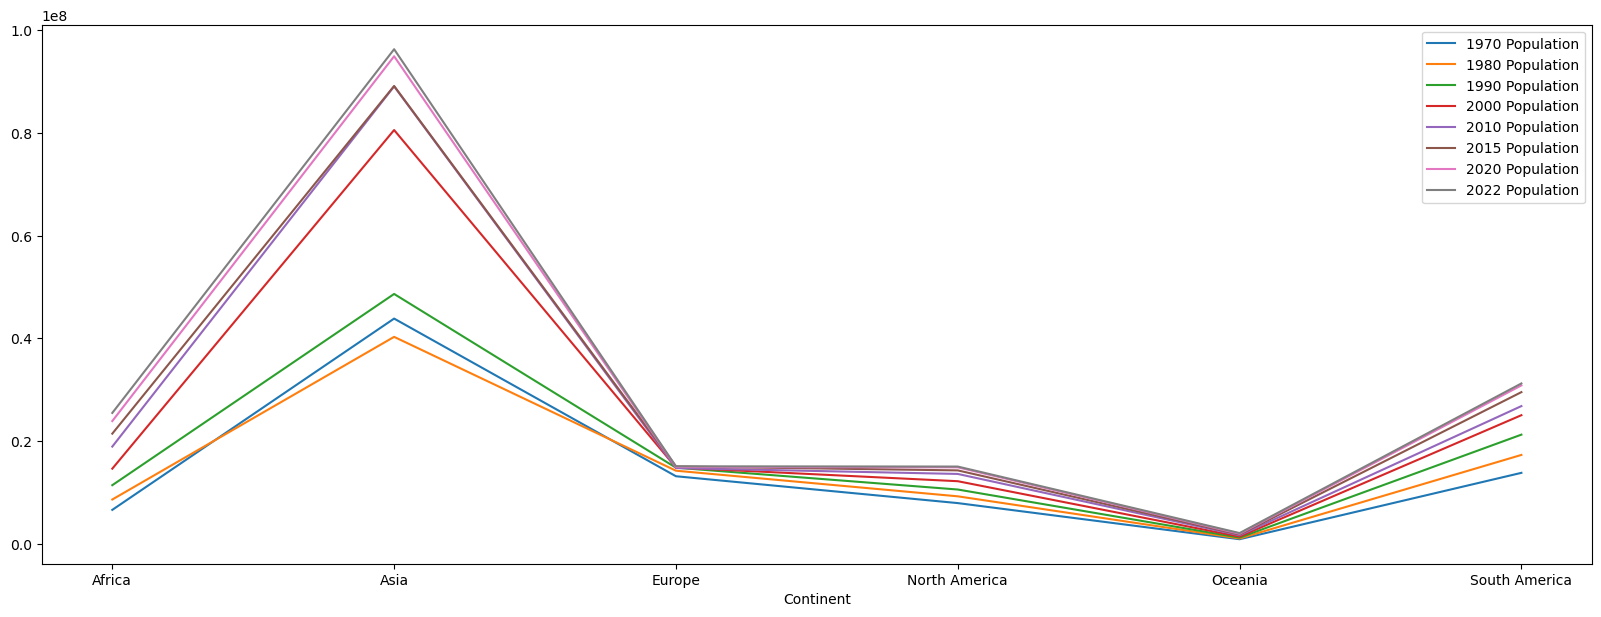

In [53]:
df2.plot()
plt.show()

In [54]:
df3 = df2.transpose()
df3

Continent,Africa,Asia,Europe,North America,Oceania,South America
1970 Population,6567175.27,43839877.83,13118479.82,7885865.15,846968.26,13781939.71
1980 Population,8586031.98,40278333.33,14200004.52,9207334.03,996532.17,17270643.29
1990 Population,11376964.52,48639995.33,14785203.94,10531660.62,1162774.87,21224743.93
2000 Population,14598365.95,80580835.11,14817685.71,12151739.60,1357512.09,25015888.69
2010 Population,18898197.31,89087770.00,14712278.68,13568016.28,1613163.65,26789395.54
2015 Population,21419703.57,89165003.64,15027454.12,14259596.25,1756664.48,29509599.71
2020 Population,23871435.26,94955134.37,14915843.92,14855914.82,1910148.96,30823574.50
2022 Population,25455879.68,96327387.31,15055371.82,15007403.40,2046386.32,31201186.29


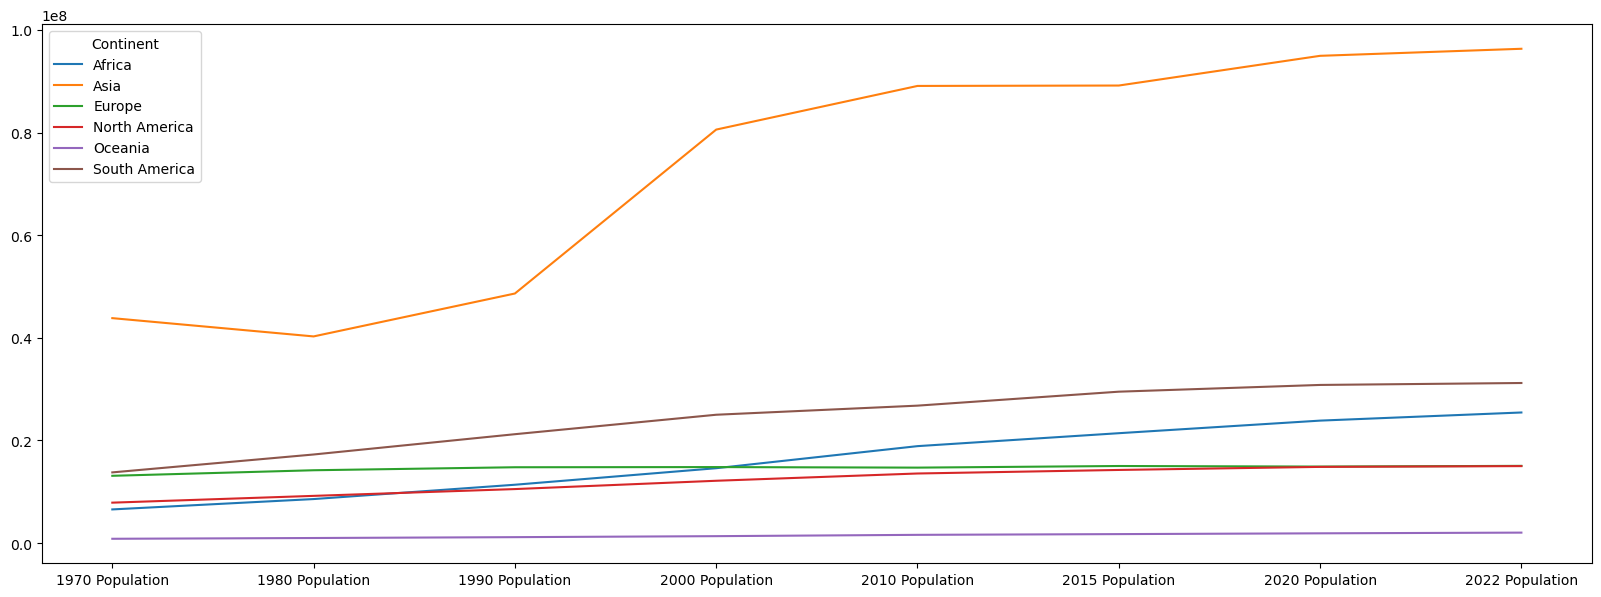

In [56]:
df3.plot()
plt.show()

<Axes: >

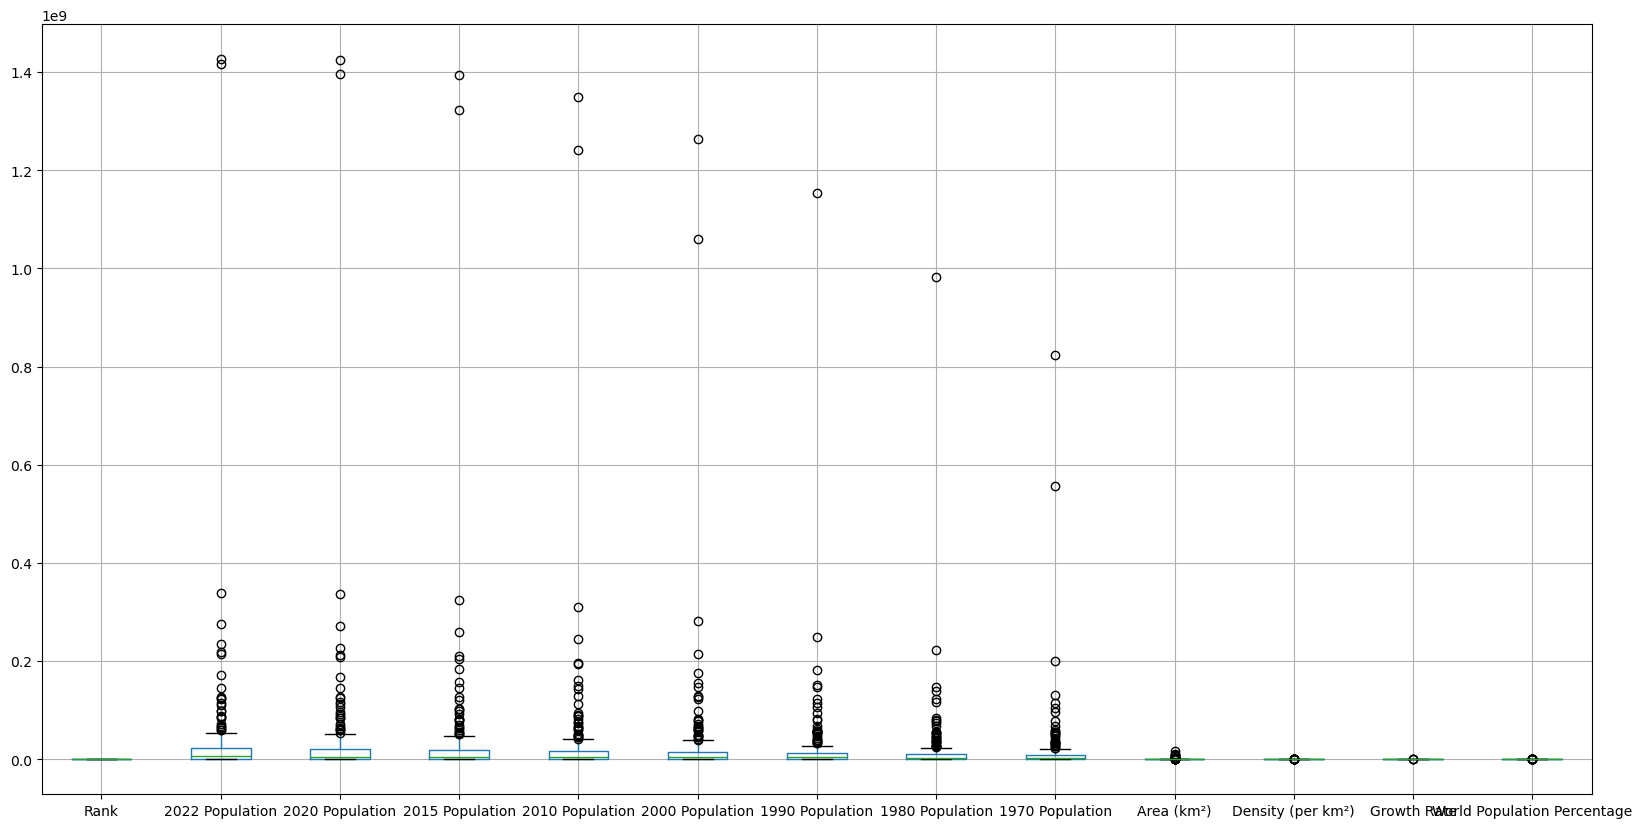

In [57]:
df.boxplot(figsize=(20,10))

In [58]:
df.select_dtypes(include='float')

,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,41128771.00,38972230.00,33753499.00,28189672.00,19542982.00,10694796.00,12486631.00,10752971.00,652230.00,63.06,1.03,0.52
1,2842321.00,2866849.00,2882481.00,2913399.00,3182021.00,3295066.00,2941651.00,2324731.00,28748.00,98.87,1.00,0.04
2,44903225.00,43451666.00,39543154.00,35856344.00,30774621.00,25518074.00,18739378.00,13795915.00,2381741.00,18.85,1.02,0.56
3,44273.00,46189.00,51368.00,54849.00,58230.00,47818.00,32886.00,27075.00,199.00,222.48,0.98,0.00
4,79824.00,77700.00,71746.00,71519.00,66097.00,53569.00,35611.00,19860.00,468.00,170.56,1.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
229,11572.00,11655.00,12182.00,13142.00,14723.00,13454.00,11315.00,9377.00,142.00,81.49,1.00,0.00
230,575986.00,556048.00,491824.00,413296.00,270375.00,178529.00,116775.00,76371.00,266000.00,2.17,1.02,0.01
231,33696614.00,32284046.00,28516545.00,24743946.00,18628700.00,13375121.00,9204938.00,6843607.00,527968.00,63.82,1.02,0.42
232,20017675.00,18927715.00,NaN,13792086.00,9891136.00,7686401.00,5720438.00,4281671.00,752612.00,26.60,1.03,0.25
